<img src="images/banner.png" style="width: 100%;">

# Transfer learning

**MSDS 2026 | COSCI223: Machine Learning 3**

*Prepared by Kristine Ann M. Carandang*

## Setup

### Modules and Libraries

In [1]:
import os
import numpy as np
import pandas as pd

import keras
from keras import layers
from keras.models import Sequential
from keras import models
from keras import regularizers
from keras.callbacks import EarlyStopping
from tensorflow import data as tf_data

from matplotlib import rcParams
import matplotlib.pyplot as plt


# Some preambles for prettification
rcParams.update({'figure.figsize': (8, 6), 'axes.spines.top': False,
                 'axes.spines.right': False, 'axes.labelsize': 12,
                 'axes.titlesize': 12, 'axes.titleweight': 'bold',
                 'lines.linewidth': 3})

In [2]:
def plot_history(history):
    """Generate the fitting history plot given the history object from
    model training

    Generates the training and validation accuracy and loss plots.

    Parameters
    ----------
    history : keras History object
        History object returned during model fitting

    Returns
    -------
    fig, axes : matplotlib Figure and Axes
        Figure and axes of the generated validation and accuracy loss
        plots
    """
    # Get accuracies and losses from history object
    accuracy = history.history['accuracy']
    loss = history.history['loss']
    val_accuracy = history.history['val_accuracy']
    val_loss = history.history['val_loss']
    
    # Generate epoch number list
    epochs = range(1, len(accuracy) + 1)

    # Initialize figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Plot epochs and accuracy/loss values
    axes[0].plot(epochs, accuracy, 'o', color='tab:blue',
                 label='Train Accuracy')
    axes[0].plot(epochs, val_accuracy, '--', color='tab:blue',
                 label='Validation Accuracy')
    axes[1].plot(epochs, loss, 'o', color='tab:orange', label='Train Loss')
    axes[1].plot(epochs, val_loss, '--', color='tab:orange',
                 label='Validation Loss')

    # Add axis labels and legends
    for ax in axes:
        ax.set_xlabel("Epochs")
        ax.legend()
    axes[0].set_ylabel("Accuracy")
    axes[1].set_ylabel("Loss")
    fig.suptitle("Fitting History Plots", fontsize=16, weight='bold')

    return fig, axes

In [3]:
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

### Cats vs Dogs Dataset

We use this dataset, which is now stored locally under the directory `PetImages`. 

#### Load the dataset

In [4]:
# training parameters
batch_size = 32
n_epochs = 15

In [5]:
# Generate a dataset
image_size = (224,224)

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)


Found 23438 files belonging to 2 classes.
Using 18751 files for training.
Using 4687 files for validation.


In [6]:
train_ds = train_ds.unbatch().take(640).batch(batch_size)
val_ds   = val_ds.unbatch().take(160).batch(batch_size)

**Visualize the data**

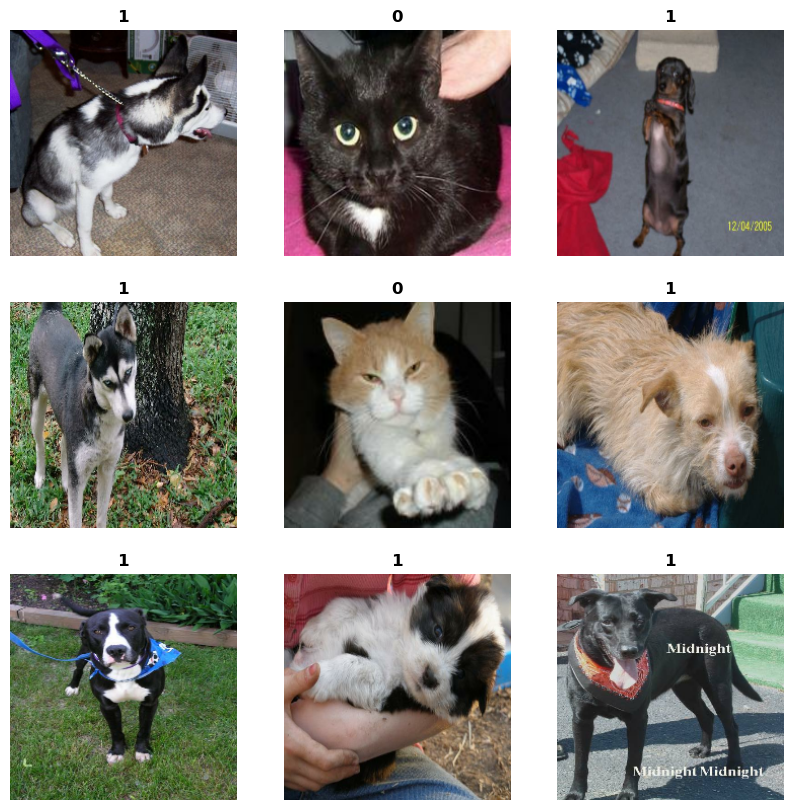

In [7]:
# Visualize the data
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

## Pretrained Model
- [CNN Pretrained Models in Keras](https://keras.io/api/applications/)

A pretrained model is a model that was previously trained on a large dataset, typically on a large-scale image-classification task.

Below are examples of pre-trained CNN with their corresponding original papers:

1. AlexNet - [Imagenet classification with deep convolutional neural networks](https://dl.acm.org/doi/abs/10.1145/3065386)
2. VGG - [Very deep convolutional networks for large-scale image recognition](https://arxiv.org/abs/1409.1556)
3. DenseNet - [Densely Connected Convolutional Networks](https://arxiv.org/abs/1608.06993)
4. ResNet - [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385)
5. EfficientNet - [EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks](https://arxiv.org/abs/1905.11946)
6. MobileNet - [MobileNetV2: Inverted Residuals and Linear Bottlenecks](https://arxiv.org/abs/1801.04381)
7. MedNet - [MedNet: pre-trained convolutional neural network model for the medical imaging tasks](https://arxiv.org/abs/2110.06512)


### Load a pretrained model

For illustration purposes, we use [VGG16](https://arxiv.org/abs/1409.1556) as an example.

In [8]:
# Load pretrained model
vgg16 = keras.applications.VGG16(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
    name="vgg16",
)

print(vgg16)

<Functional name=vgg16, built=True>


In [9]:
vgg16.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

## Transfer learning approaches

### Pretrained model as a feature extractor

Feature extraction consists of using the representations learned by a previously trained model to extract interesting features from new samples. These features are then run through a new classifier, which is trained from scratch.

In [10]:
# Load pretrained model without the classifier
base_model = keras.applications.VGG16(
    include_top=False, # without the classifier
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
    name="vgg16",
)

In [20]:
# Set to false since we'd be using the existing weights
base_model.trainable = False

In [21]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

#### Fast feature extraction

In [22]:
def extract_features(dataset):
    features = []
    labels = []
    
    for batch_images, batch_labels in dataset:
        batch_features = base_model(batch_images, training=False)
        features.append(batch_features.numpy())
        labels.append(batch_labels.numpy())
    
    return np.concatenate(features), np.concatenate(labels)

In [23]:
train_features, train_labels = extract_features(train_ds)
val_features, val_labels = extract_features(val_ds)

In [24]:
# np.save("train_features.npy", train_features)
# np.save("train_labels.npy", train_labels)

# np.save("val_features.npy", val_features)
# np.save("val_labels.npy", val_labels)

In [25]:
train_features = train_features.reshape(train_features.shape[0], -1)
val_features   = val_features.reshape(val_features.shape[0], -1)

ffe = models.Sequential([
    layers.Dense(256, activation='relu', input_dim=7*7*512),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

ffe.compile(optimizer='adamax',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Perform model fitting
ffe_hx = ffe.fit(
    train_features, train_labels,
    epochs=n_epochs,
    validation_data=[val_features, val_labels],
    callbacks=[early_stop]
)

/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8656 - loss: 54.7623 - val_accuracy: 0.9375 - val_loss: 18.0590
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9297 - loss: 18.6256 - val_accuracy: 0.9375 - val_loss: 17.1782
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9438 - loss: 14.6200 - val_accuracy: 0.9563 - val_loss: 12.6944
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9516 - loss: 11.8318 - val_accuracy: 0.9500 - val_loss: 13.0980
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9469 - loss: 10.5224 - val_accuracy: 0.9500 - val_loss: 13.0807
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9484 - loss: 8.3102 - val_accuracy: 0.9438 - val_loss: 13.5527


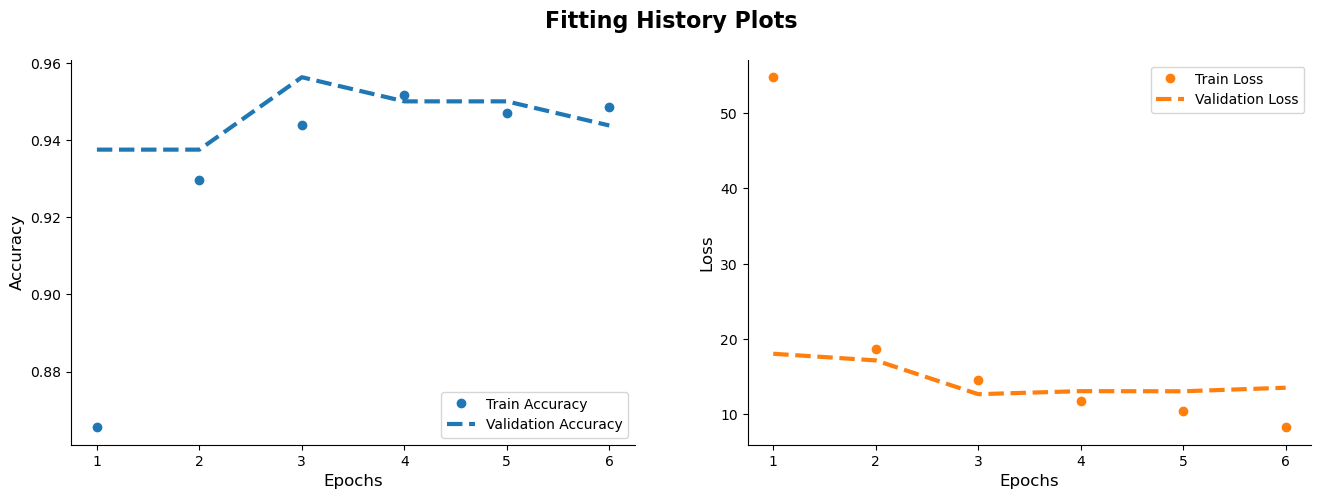

In [31]:
plot_history(ffe_hx);

#### Slow feature extraction

In [27]:

inputs = layers.Input(shape=image_size + (3,))

# Model-specific preprocessing
x = layers.Rescaling(1./127.5, offset=-1)(inputs)

# Add data augmentation layers (optional)
x = layers.RandomFlip("horizontal")(x)
x = layers.RandomRotation(0.1)(x)
x = layers.RandomZoom(0.1)(x)
x = layers.RandomContrast(0.1)(x)

# Pretrained feature extractor
x = base_model(x, training=False)

# New classifier
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

sfe = models.Model(inputs, outputs)

In [28]:
sfe.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,320,449 (62.26 MB)

 Trainable params: 1,605,761 (6.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [29]:
# Perform the model completion step
sfe.compile(optimizer='adamax',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Perform model fitting
sfe_hx = sfe.fit(
    train_ds,
    epochs=n_epochs,
    validation_data=val_ds,
    callbacks=[early_stop]
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.7359 - loss: 0.5580 - val_accuracy: 0.9125 - val_loss: 0.3829
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.7828 - loss: 0.4486 - val_accuracy: 0.9062 - val_loss: 0.4273
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.7734 - loss: 0.4536 - val_accuracy: 0.9125 - val_loss: 0.4450
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.7953 - loss: 0.4336 - val_accuracy: 0.9125 - val_loss: 0.4368


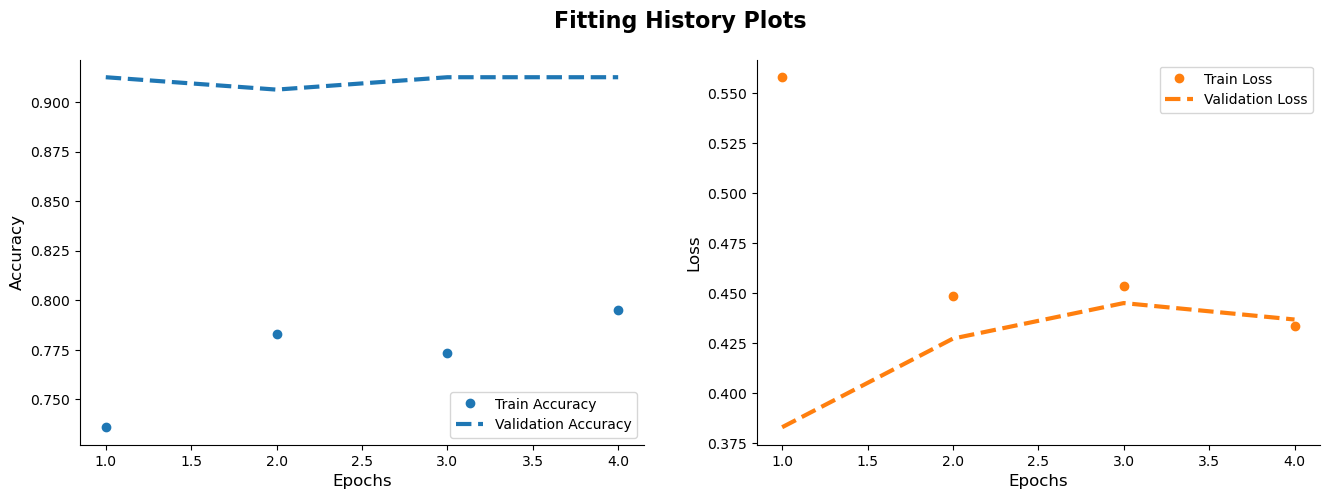

In [30]:
plot_history(sfe_hx);

### Pretrained model with fine-tuning

Fine-tuning consists of unfreezing the frozen model base used for feature extraction and jointly training both the newly added part of the model (in this case, the fully connected classifier) and the base model. This is called fine-tuning because it slightly adjusts the more abstract representations of the model being reused to make them more relevant for the problem at hand.

In [15]:
# Unfreeze all layers first
base_model.trainable = True

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze block5 only
for layer in base_model.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True

In [16]:
# Check which layers are trainable
for layer in base_model.layers:
    print(layer.name, layer.trainable)

input_layer_1 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [17]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [18]:
inputs = layers.Input(shape=image_size + (3,))

# Model-specific preprocessing
x = layers.Rescaling(1./127.5, offset=-1)(inputs)

# Add data augmentation layers (optional)
# x = layers.RandomFlip("horizontal")(x)
# x = layers.RandomRotation(0.1)(x)
# x = layers.RandomZoom(0.1)(x)
# x = layers.RandomContrast(0.1)(x)

# Pretrained feature extractor
x = base_model(x, training=True)

# New classifier
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

ft = models.Model(inputs, outputs)



# Perform the model completion step
ft.compile(optimizer='adamax',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Perform model fitting
ft_hx = ft.fit(
    train_ds,
    epochs=n_epochs,
    validation_data=val_ds,
    callbacks=[early_stop]
)

Epoch 1/15
     20/Unknown 57s 3s/step - accuracy: 0.5394 - loss: 1.1704

/opt/conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


20/20 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.5094 - loss: 0.8886 - val_accuracy: 0.5250 - val_loss: 0.6922
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.5328 - loss: 0.6939 - val_accuracy: 0.5312 - val_loss: 0.6921
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.5063 - loss: 0.6937 - val_accuracy: 0.5250 - val_loss: 0.6912
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.4891 - loss: 0.6912 - val_accuracy: 0.5250 - val_loss: 0.6885
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.4875 - loss: 0.6887 - val_accuracy: 0.5250 - val_loss: 0.6747
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.5484 - loss: 0.6446 - val_accuracy: 0.6187 - val_loss: 0.5619
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.7000 - loss: 0.5749 - val_accuracy: 0.7188 - val_loss: 0.5212
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.7219 - loss: 0.5213 - val_accuracy: 0.8562 - val_loss: 0.4724
Epo

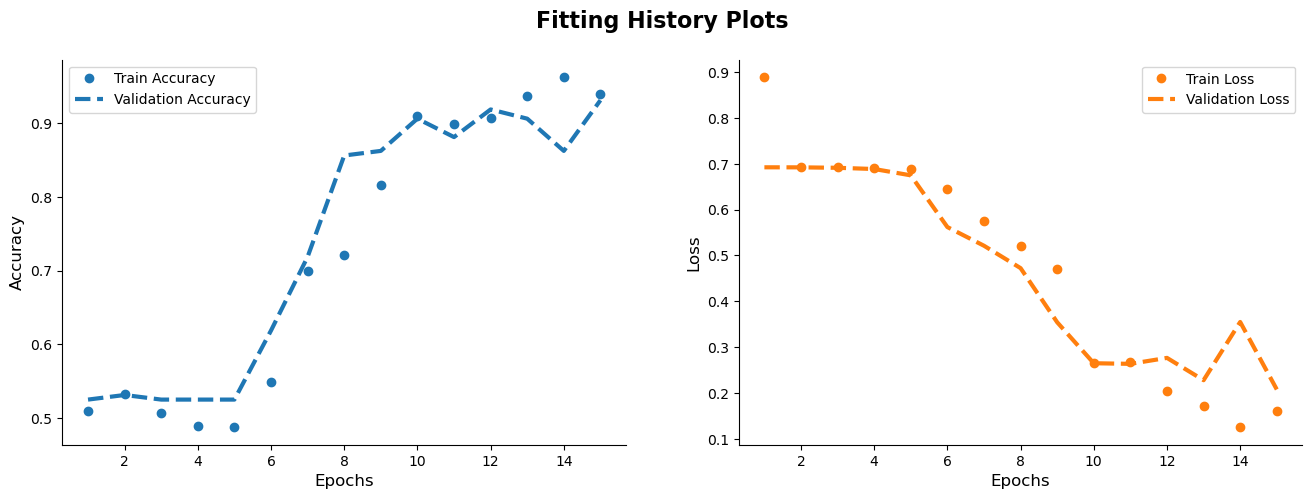

In [19]:
# Plot training-validation accuracy
plot_history(ft_hx);

<div class="alert alert-block alert-info"> 
<b>EXPLORATION TASK</b>
<br>
Try unfreezing more blocks, or blocks in the earlier layers. Note what happens.
<br>
Also try incorporating data augmentation.
<br>
</div>

## References

- Chollet, F., & Chollet, F. (2021). Deep learning with Python. simon and schuster.
- Bishop, C. M., & Bishop, H. (2023). Deep learning: Foundations and concepts. Springer Nature.
- Goodfellow, I., Bengio, Y., Courville, A., & Bengio, Y. (2016). Deep learning (Vol. 1, No. 2, pp. 1-800). Cambridge: MIT press.
- Monterola, CM. ML3 Notebook 2A.
- Simon, J. D. (2024). Understanding Deep Learning.

<img src="images/banner-down.png" style="width: 100%;">